# DBGSOM Paper Benchmarks

Reproducible results for the JOSS paper. Run the scripts first:

```bash
uv run python paper_benchmarks/clustering.py
uv run python paper_benchmarks/scaling.py
```


In [70]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("results")

## Clustering — Digits dataset


In [71]:
df_cluster = pd.read_csv(RESULTS / "clustering_digits.csv", index_col="Algorithm").T
df_cluster

Algorithm,DBGSOM,MiniSom,SuSi,torchsom,KMeans
n_prototypes,121,121,121,121,121
Time (s),0.94,3.25,0.15,1.18,1.79
QE,4.84,4.84,5.69,5.95,4.3
TE,0.0257,0.1833,0.0861,0.0889,—
ARI,0.17,0.17,0.25,0.5,0.17
Silhouette,-0.02,0.0,-0.08,-0.04,0.05


## Scaling — training time vs. N


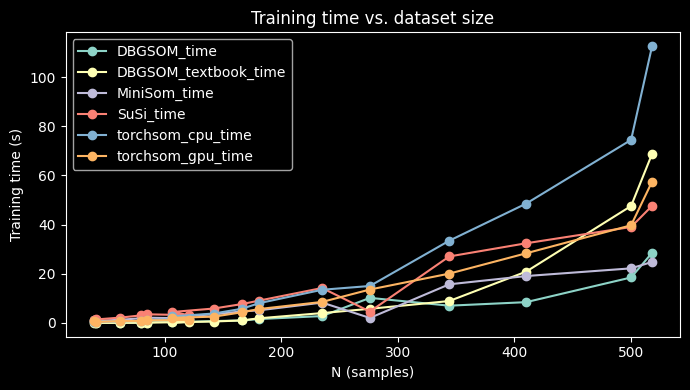

,DBGSOM_time,DBGSOM_n_nodes,DBGSOM_qe,DBGSOM_te,DBGSOM_textbook_time,DBGSOM_textbook_n_nodes,DBGSOM_textbook_qe,MiniSom_time,MiniSom_n_nodes,MiniSom_qe,SuSi_time,SuSi_n_nodes,SuSi_qe,torchsom_cpu_time,torchsom_cpu_n_nodes,torchsom_cpu_qe,torchsom_gpu_time,torchsom_gpu_n_nodes,torchsom_gpu_qe
N,,,,,,,,,,,,,,,,,,,
1000,1.312,39,0.9841,0.0130,0.071,39,0.9869,0.821,49,0.9781,1.276,49,1.2410,0.517,49,2.5559,0.647,49,2.2571
1414,0.063,42,0.9831,0.0000,0.044,41,0.9878,0.879,49,0.9895,1.430,49,1.1918,0.436,49,2.5333,0.409,49,2.3021
2000,0.076,63,0.9705,0.0310,0.071,62,0.9694,1.317,64,0.9818,2.197,64,1.0318,0.666,64,1.9672,0.796,64,2.0270
2828,0.135,84,0.9646,0.0644,0.093,80,0.9609,1.934,100,0.9643,3.105,100,0.9978,0.827,100,1.9083,0.827,100,2.0071
4000,0.190,93,0.9584,0.0625,0.127,85,0.9587,2.152,100,0.9700,3.531,100,0.9981,1.242,100,1.9421,1.078,100,1.9563
5656,1.207,84,0.9613,0.0645,0.403,121,0.9474,1.870,100,0.9687,3.195,100,0.9956,1.667,100,1.9109,1.207,100,2.0031
8000,0.281,108,0.9500,0.0602,0.281,106,0.9508,2.528,121,0.9691,4.460,121,0.9852,2.676,121,2.0113,2.098,121,2.0815
11313,0.782,141,0.9461,0.0671,0.604,142,0.9446,3.507,144,0.9682,5.878,144,0.9766,3.848,144,2.0376,2.576,144,2.0419
16000,1.029,172,0.9415,0.1109,1.033,166,0.9404,4.704,196,0.9672,7.676,196,0.9638,5.760,196,2.0348,4.336,196,2.1308


In [75]:
df_scale = pd.read_csv(RESULTS / "scaling.csv", index_col="N")
times = [
    "DBGSOM_time",
    "DBGSOM_textbook_time",
    "MiniSom_time",
    "SuSi_time",
    "torchsom_cpu_time",
    "torchsom_gpu_time",
]

fig, ax = plt.subplots(figsize=(7, 4))
for col in df_scale[times]:
    # ax.plot(df_scale.index, df_scale[col], marker="o", label=col)
    ax.plot(df_scale["DBGSOM_textbook_n_nodes"], df_scale[col], marker="o", label=col)

ax.set_xlabel("N (samples)")
ax.set_ylabel("Training time (s)")
ax.set_title("Training time vs. dataset size")
ax.legend()
plt.tight_layout()
# plt.savefig(RESULTS / "scaling_plot.png", dpi=150)
plt.show()
df_scale

In [77]:
df_scale[times]

,DBGSOM_time,DBGSOM_textbook_time,MiniSom_time,SuSi_time,torchsom_cpu_time,torchsom_gpu_time
N,,,,,,
1000,1.312,0.071,0.821,1.276,0.517,0.647
1414,0.063,0.044,0.879,1.430,0.436,0.409
2000,0.076,0.071,1.317,2.197,0.666,0.796
2828,0.135,0.093,1.934,3.105,0.827,0.827
4000,0.190,0.127,2.152,3.531,1.242,1.078
5656,1.207,0.403,1.870,3.195,1.667,1.207
8000,0.281,0.281,2.528,4.460,2.676,2.098
11313,0.782,0.604,3.507,5.878,3.848,2.576
16000,1.029,1.033,4.704,7.676,5.760,4.336


In [76]:
df_scale[["DBGSOM_textbook_n_nodes", "DBGSOM_n_nodes"]]

,DBGSOM_textbook_n_nodes,DBGSOM_n_nodes
N,,
1000,39,39
1414,41,42
2000,62,63
2828,80,84
4000,85,93
5656,121,84
8000,106,108
11313,142,141
16000,166,172
